In [10]:
import sys
import os

# Move to the project root so that src/ and data/ can be found
while not os.path.isdir("src") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

sys.path.insert(0, "src")

import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.indicators import sma

# Load the Egyptian Exchange dataset
feed = DataFeed.from_dir("data/egx")

# Select one asset
asset_index = 0
symbol = feed.symbols[asset_index]

dates = feed.dates
prices = feed.close[:, asset_index].astype(float)

print("Selected asset:", symbol)
print("Number of historical days:", len(prices))
print("First available price:", prices[np.isfinite(prices)][0])

Selected asset: ABUK
Number of historical days: 1159
First available price: 19.700000762939453


In [11]:
symbol = "ABUK"

asset_index = feed.symbols.index(symbol)

dates = feed.dates
prices = feed.close[:, asset_index]

In [12]:
ma9 = sma(prices, 9)
ma20 = sma(prices, 20)

print("MA9 and MA20 calculated successfully.")
print("MA9 length:", len(ma9))
print("MA20 length:", len(ma20))


MA9 and MA20 calculated successfully.
MA9 length: 1159
MA20 length: 1159


In [14]:
feed = DataFeed.from_dir("data/egx")

print(feed.symbols)

['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']


In [15]:
initial_cash = 1000.0

cash = initial_cash
shares = 0

portfolio_values = np.full(len(prices), np.nan)

buy_indices = []
sell_indices = []
transactions = []

last_valid_price = np.nan

for i in range(len(prices)):
    current_price = prices[i]

    # Handle a missing price
    if not np.isfinite(current_price):
        if np.isfinite(last_valid_price):
            portfolio_values[i] = cash + shares * last_valid_price
        continue

    last_valid_price = current_price

    # Trade only after both moving averages are available
    if np.isfinite(ma9[i]) and np.isfinite(ma20[i]):

        # Buy when MA9 is above MA20 and we do not own shares
        if ma9[i] > ma20[i] and shares == 0:
            quantity = int(cash // current_price)

            if quantity > 0:
                cost = quantity * current_price
                cash -= cost
                shares = quantity

                buy_indices.append(i)
                transactions.append(
                    {
                        "date": dates[i],
                        "operation": "BUY",
                        "price": current_price,
                        "shares": quantity,
                    }
                )

        # Sell when MA9 is below MA20 and we own shares
        elif ma9[i] < ma20[i] and shares > 0:
            sale_value = shares * current_price

            transactions.append(
                {
                    "date": dates[i],
                    "operation": "SELL",
                    "price": current_price,
                    "shares": shares,
                }
            )

            cash += sale_value
            shares = 0
            sell_indices.append(i)

    # Mark-to-market portfolio value at the end of the day
    portfolio_values[i] = cash + shares * current_price

print("Walk-forward backtest completed.")

Walk-forward backtest completed.


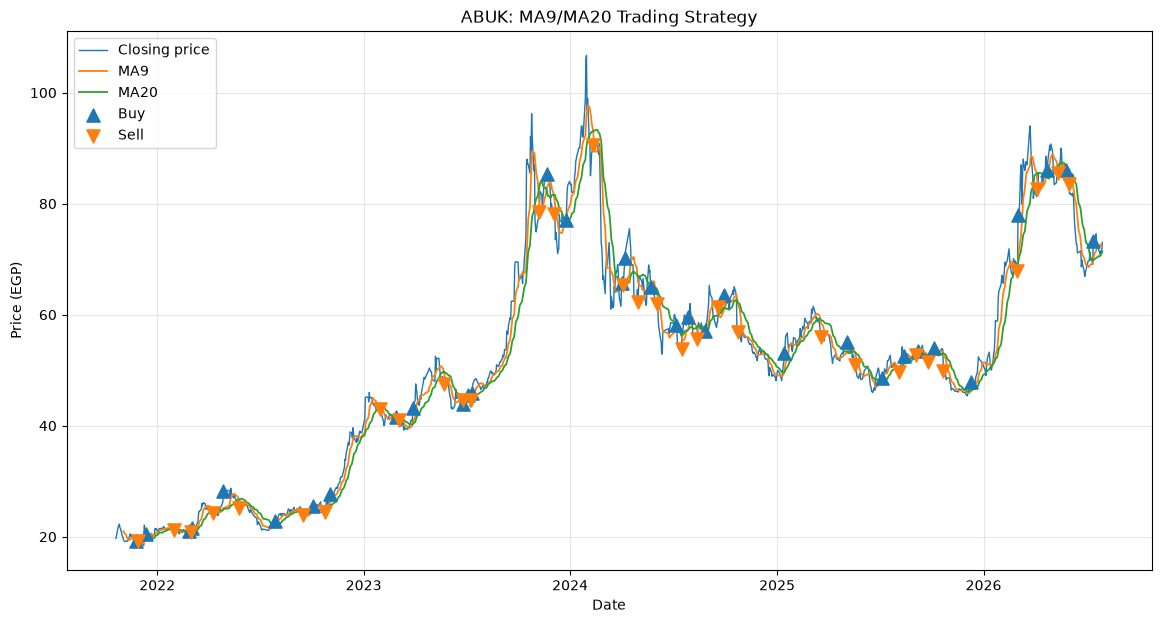

In [16]:
plt.figure(figsize=(14, 7))

plt.plot(dates, prices, label="Closing price", linewidth=1)
plt.plot(dates, ma9, label="MA9", linewidth=1.3)
plt.plot(dates, ma20, label="MA20", linewidth=1.3)

if buy_indices:
    plt.scatter(
        np.asarray(dates)[buy_indices],
        prices[buy_indices],
        marker="^",
        s=90,
        label="Buy",
        zorder=5,
    )

if sell_indices:
    plt.scatter(
        np.asarray(dates)[sell_indices],
        prices[sell_indices],
        marker="v",
        s=90,
        label="Sell",
        zorder=5,
    )

plt.title(f"{symbol}: MA9/MA20 Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Price (EGP)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

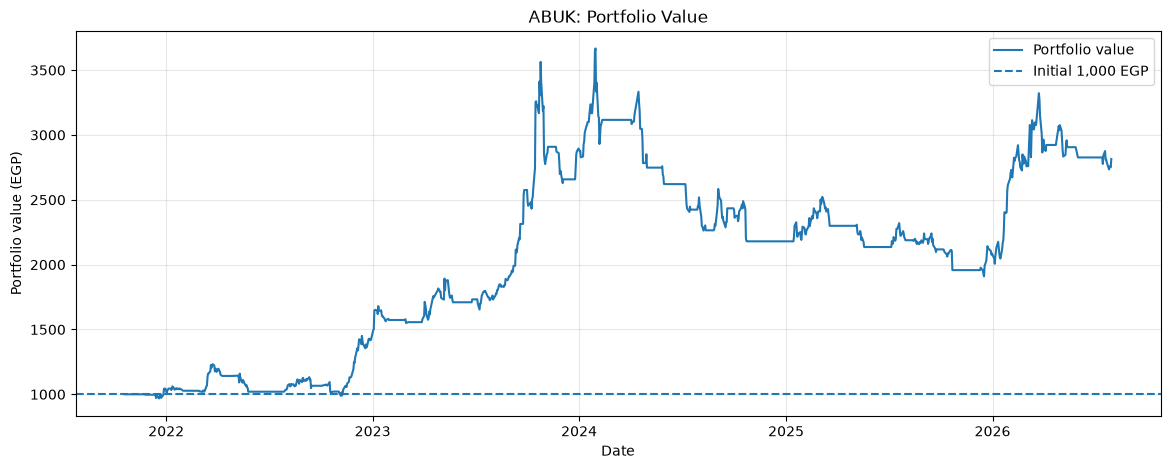

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(
    dates,
    portfolio_values,
    label="Portfolio value",
    linewidth=1.5,
)

plt.axhline(
    initial_cash,
    linestyle="--",
    label="Initial 1,000 EGP",
)

plt.title(f"{symbol}: Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio value (EGP)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
for transaction in transactions:
    print(
        transaction["date"],
        transaction["operation"],
        "| Price:",
        round(transaction["price"], 2),
        "| Shares:",
        transaction["shares"],
    )
    

2021-11-24 00:00:00 BUY | Price: 19.22 | Shares: 52
2021-11-28 00:00:00 SELL | Price: 19.16 | Shares: 52
2021-12-13 00:00:00 BUY | Price: 20.5 | Shares: 48
2022-01-31 00:00:00 SELL | Price: 21.14 | Shares: 48
2022-02-27 00:00:00 BUY | Price: 20.99 | Shares: 48
2022-03-01 00:00:00 SELL | Price: 20.87 | Shares: 48
2022-03-03 00:00:00 BUY | Price: 21.66 | Shares: 47
2022-04-10 00:00:00 SELL | Price: 24.21 | Shares: 47
2022-04-28 00:00:00 BUY | Price: 28.29 | Shares: 40
2022-05-26 00:00:00 SELL | Price: 25.25 | Shares: 40
2022-07-28 00:00:00 BUY | Price: 22.86 | Shares: 44
2022-09-15 00:00:00 SELL | Price: 23.9 | Shares: 44
2022-10-04 00:00:00 BUY | Price: 25.59 | Shares: 41
2022-10-24 00:00:00 SELL | Price: 24.5 | Shares: 41
2022-11-02 00:00:00 BUY | Price: 27.7 | Shares: 36
2023-01-30 00:00:00 SELL | Price: 43.03 | Shares: 36
2023-02-27 00:00:00 BUY | Price: 41.54 | Shares: 37
2023-03-05 00:00:00 SELL | Price: 41.09 | Shares: 37
2023-03-29 00:00:00 BUY | Price: 43.17 | Shares: 36
2023-05

In [19]:
final_value = portfolio_values[np.isfinite(portfolio_values)][-1]

print("Final Portfolio Value:", round(final_value, 2), "EGP")

Final Portfolio Value: 2814.81 EGP


In [20]:
running_max = np.maximum.accumulate(portfolio_values)

drawdown = (running_max - portfolio_values) / running_max

max_drawdown = np.nanmax(drawdown)

print("Maximum Drawdown:", round(max_drawdown * 100, 2), "%")

Maximum Drawdown: 47.91 %


In [21]:
print("Number of buys:", len(buy_indices))
print("Number of sells:", len(sell_indices))

Number of buys: 33
Number of sells: 32
